In [1]:
!pip install torch torchvision matplotlib tqdm opencv-python-headless

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import EuroSAT
import os

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [3]:
dataset = EuroSAT(root="data", download=True, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

100%|██████████| 94.3M/94.3M [00:00<00:00, 320MB/s]


In [6]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


#0: AnnualCrop(S), 1: Forest(U), 2: HerbaceousVeg(S), 3: Highway(U), 4: Industrial(U),
#5: Pasture(S), 6: PermanentCrop(S), 7: Residential(U), 8: River(U), 9: Sea(U)
safe_classes = [0, 2, 5, 6]

def train_model(epochs=5):
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} Complete")

train_model(epochs=6)

Epoch 1 Complete
Epoch 2 Complete
Epoch 3 Complete
Epoch 4 Complete
Epoch 5 Complete
Epoch 6 Complete


In [8]:
import matplotlib.pyplot as plt
import torch

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

dataiter = iter(test_loader)
images, labels = next(dataiter)

images = images[:4].to(device)
labels = labels[:4]

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

images = images.cpu()
predicted = predicted.cpu()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig = plt.figure(figsize=(16, 4))

<Figure size 1600x400 with 0 Axes>

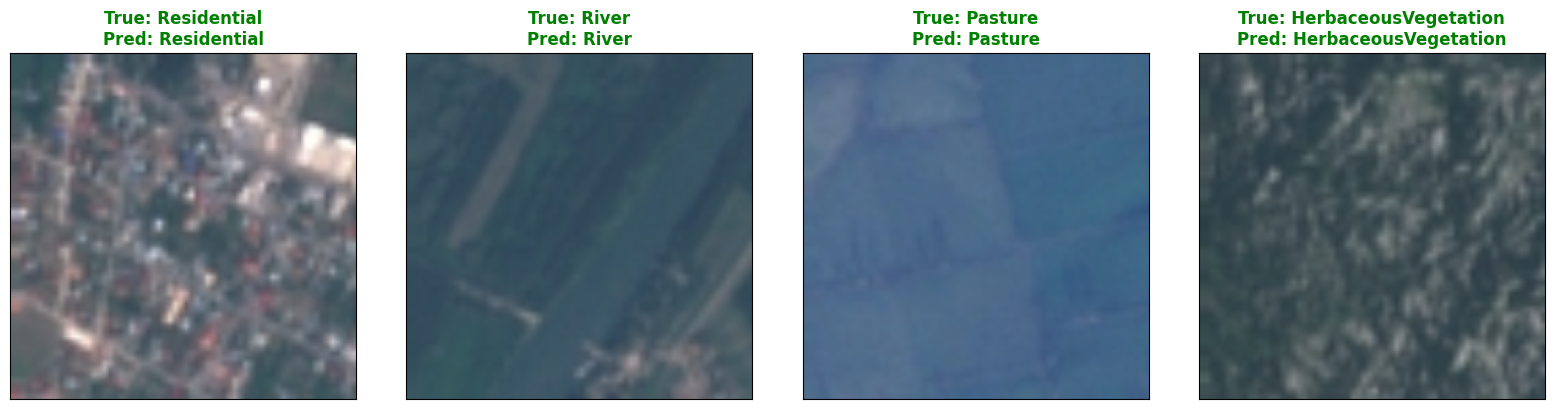

In [9]:
fig = plt.figure(figsize=(16, 4))

for i in range(4):
    ax = fig.add_subplot(1, 4, i+1, xticks=[], yticks=[])

    img = images[i] * std + mean

    img = torch.clamp(img, 0, 1)

    img = img.permute(1, 2, 0).numpy()

    plt.imshow(img)

    true_label = dataset.classes[labels[i]]
    pred_label = dataset.classes[predicted[i]]

    color = "green" if true_label == pred_label else "red"

    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
import torch

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()

correct = 0
total = 0

print("Running validation on EuroSAT test set")

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(" FINAL TERRAIN MODEL METRICS ")
print(f"Overall Accuracy: {accuracy:.2f}%")

Running validation on EuroSAT test set
 FINAL TERRAIN MODEL METRICS 
Overall Accuracy: 95.24%
